# Explore a survey for top-tail diagnostics

Choose one `.dta` file in `01-input/country`, then run the cells in order. The notebook does not modify survey data.

**Weights are used everywhere:** weighted quantiles define the LIS ceiling and p90 threshold; weighted means, histograms, CCDFs, and Pareto estimation represent the survey population rather than giving every sampled record equal importance.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(
    (
        path
        for path in [Path.cwd(), *Path.cwd().parents]
        if (path / '01-input' / 'country').exists()
    ),
    None,
)

if ROOT is None:
    raise FileNotFoundError(
        'Could not find the bindata_check repository above the current notebook directory.'
    )

INPUT_DIR = ROOT / '01-input' / 'country'
OUTPUT_DIR = ROOT / 'top_censoring' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

available_files = sorted(path.name for path in INPUT_DIR.glob('*.dta'))
available_files

['AGO_2000.dta',
 'AGO_2008.dta',
 'BEL_2000.dta',
 'BLZ_1993.dta',
 'BLZ_1997.dta',
 'BWA_1993.dta',
 'CHE_2000.dta',
 'ECU_2006.dta',
 'KEN_1992.dta',
 'MWI_1997.dta',
 'MWI_2004.dta',
 'MWI_2019.dta',
 'SWZ_1994.dta',
 'SYC_1999.dta',
 'ZWE_2019.dta']

In [3]:
# Change this value, then rerun this cell and all cells below.
SURVEY_FILE = 'BLZ_1993.dta'

if SURVEY_FILE not in available_files:
    raise ValueError(f'{SURVEY_FILE} is not in 01-input/country. Choose one of: {available_files}')

df = pd.read_stata(INPUT_DIR / SURVEY_FILE)
print(f'Loaded {SURVEY_FILE}: {len(df):,} rows and {len(df.columns):,} columns')
display(df.head())
print('Columns:')
print(', '.join(df.columns))

Loaded BLZ_1993.dta: 14,143 rows and 40 columns


,regioncode,countrycode,datayear,hhid,hsize,weight,urban,welfare,coveragetype,datatype,...,comparable,cpi2005,icp2005,cpi_data_level,cpi2011_SM26,cpi2017_SM26,cpi2021_SM26,icp2011_SM26,icp2017_SM26,icp2021_SM26
0,LAC,BLZ,1993.0,1.0,4.0,14,Urban,16250.0,National,Income,...,NaN,NaN,NaN,2,0.68575,0.65931,0.634966,1.174023,1.309024,1.116539
1,LAC,BLZ,1993.0,2.0,4.0,14,Urban,16250.0,National,Income,...,NaN,NaN,NaN,2,0.68575,0.65931,0.634966,1.174023,1.309024,1.116539
2,LAC,BLZ,1993.0,3.0,4.0,14,Urban,16250.0,National,Income,...,NaN,NaN,NaN,2,0.68575,0.65931,0.634966,1.174023,1.309024,1.116539
3,LAC,BLZ,1993.0,4.0,4.0,14,Urban,16250.0,National,Income,...,NaN,NaN,NaN,2,0.68575,0.65931,0.634966,1.174023,1.309024,1.116539
4,LAC,BLZ,1993.0,5.0,3.0,14,Urban,5000.0,National,Income,...,NaN,NaN,NaN,2,0.68575,0.65931,0.634966,1.174023,1.309024,1.116539


Columns:
regioncode, countrycode, datayear, hhid, hsize, weight, urban, welfare, coveragetype, datatype, code, year, survname, cpi_domain, cpi_domain_value, cpi2021_unadj, cpi2017_unadj, cpi2011_unadj, cpi2011, cpi2017, cpi2021, icp2011, icp2017, icp2021, comparability, cpi_replication, cpi_domain_var, icpreplication, icpdomain_var, icpdomain_value, comparable, cpi2005, icp2005, cpi_data_level, cpi2011_SM26, cpi2017_SM26, cpi2021_SM26, icp2011_SM26, icp2017_SM26, icp2021_SM26


In [4]:
def choose_weight_column(columns):
    for candidate in ['weight_p', 'weight', 'weight_h']:
        if candidate in columns:
            return candidate
    raise ValueError('No recognized weight column found.')

def weighted_quantile(values, weights, probabilities):
    order = np.argsort(values)
    values = np.asarray(values)[order]
    weights = np.asarray(weights)[order]
    cumulative_weight = np.cumsum(weights) / weights.sum()
    return np.array([values[np.searchsorted(cumulative_weight, p, side='left')] for p in probabilities])

weight_column = choose_weight_column(df.columns)
required = ['welfare', weight_column, 'cpi2021', 'icp2021']
missing = [column for column in required if column not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df['welfare_ppp_day'] = df['welfare'] / (df['cpi2021'] * df['icp2021'] * 365)
analysis = df.loc[
    np.isfinite(df['welfare_ppp_day']) & (df['welfare_ppp_day'] > 0) &
    np.isfinite(df[weight_column]) & (df[weight_column] > 0),
    ['welfare_ppp_day', weight_column]
].copy()
analysis = analysis.rename(columns={weight_column: 'weight'})

print('Weight column:', weight_column)
print('Valid records:', f'{len(analysis):,}')
print('Population represented:', f"{analysis['weight'].sum():,.0f}")

Weight column: weight
Valid records: 9,097
Population represented: 131,218


In [5]:
x = analysis['welfare_ppp_day'].to_numpy()
w = analysis['weight'].to_numpy()
q01, q25, q50, q75, q90, q95, q99 = weighted_quantile(x, w, [0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

summary = pd.DataFrame({
    'statistic': ['p1', 'p25', 'median', 'p75', 'p90', 'p95', 'p99', 'weighted mean', 'maximum'],
    'welfare_ppp_day': [q01, q25, q50, q75, q90, q95, q99, np.average(x, weights=w), x.max()]
})
display(summary.round({'welfare_ppp_day': 3}))

,statistic,welfare_ppp_day
0,p1,0.322
1,p25,3.710
2,median,6.415
3,p75,11.593
4,p90,22.082
5,p95,32.461
6,p99,63.119
7,weighted mean,12.866
8,maximum,3477.966


LIS ceiling (k=3): 353.80 PPP USD/day
Records above ceiling: 22
Weighted population share above ceiling: 0.246%
Welfare share above ceiling: 20.090%


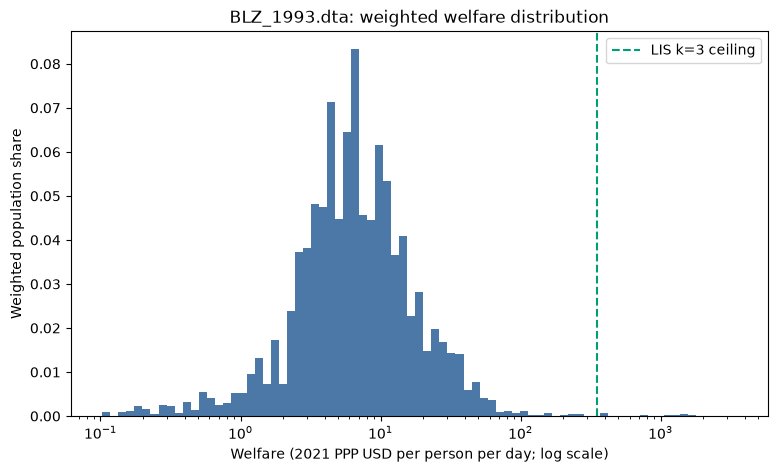

In [6]:
# LIS top ceiling is computed on log welfare.
q1_log, q3_log = weighted_quantile(np.log(x), w, [0.25, 0.75])
lis_ceiling = np.exp(q3_log + 3 * (q3_log - q1_log))
above_lis = x > lis_ceiling

print(f'LIS ceiling (k=3): {lis_ceiling:,.2f} PPP USD/day')
print(f'Records above ceiling: {above_lis.sum():,}')
print(f'Weighted population share above ceiling: {w[above_lis].sum() / w.sum():.3%}')
print(f'Welfare share above ceiling: {(x[above_lis] * w[above_lis]).sum() / (x * w).sum():.3%}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(x, bins=np.geomspace(x.min(), x.max(), 80), weights=w / w.sum(), color='#4C78A8')
ax.axvline(lis_ceiling, color='#009E73', linestyle='--', label='LIS k=3 ceiling')
ax.set_xscale('log')
ax.set_xlabel('Welfare (2021 PPP USD per person per day; log scale)')
ax.set_ylabel('Weighted population share')
ax.set_title(f'{SURVEY_FILE}: weighted welfare distribution')
ax.legend()
plt.show()

Pareto threshold: p90 = 22.08
Pareto alpha: 1.806


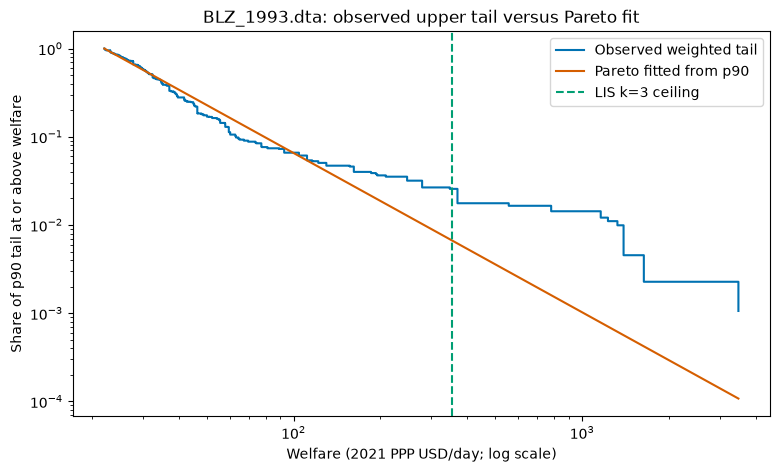

In [7]:
# Pareto fit to the top 10% of the weighted distribution.
p90 = weighted_quantile(x, w, [0.90])[0]
in_tail = x >= p90
tail_x = x[in_tail]
tail_w = w[in_tail]
pareto_alpha = tail_w.sum() / np.sum(tail_w * np.log(tail_x / p90))

order = np.argsort(tail_x)
tail_x = tail_x[order]
tail_w = tail_w[order]
empirical_ccdf = np.cumsum(tail_w[::-1])[::-1] / tail_w.sum()
pareto_ccdf = (p90 / tail_x) ** pareto_alpha

print(f'Pareto threshold: p90 = {p90:,.2f}')
print(f'Pareto alpha: {pareto_alpha:.3f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.step(tail_x, empirical_ccdf, where='post', color='#0072B2', label='Observed weighted tail')
ax.plot(tail_x, pareto_ccdf, color='#D55E00', label='Pareto fitted from p90')
ax.axvline(lis_ceiling, color='#009E73', linestyle='--', label='LIS k=3 ceiling')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Welfare (2021 PPP USD/day; log scale)')
ax.set_ylabel('Share of p90 tail at or above welfare')
ax.set_title(f'{SURVEY_FILE}: observed upper tail versus Pareto fit')
ax.legend()
plt.show()

In [7]:
# Inspect the highest welfare values. Do not interpret them as errors solely from this table.
top_records = df.loc[
    np.isfinite(df['welfare_ppp_day']) & np.isfinite(df[weight_column]),
    [column for column in ['hhid', 'welfare', 'welfare_ppp_day', weight_column, 'hsize', 'urban', 'year', 'survname'] if column in df.columns]
].sort_values('welfare_ppp_day', ascending=False).head(20)
display(top_records)

,hhid,welfare,welfare_ppp_day,weight,hsize,urban,year,survname
1749,1750.0,900000.000000,3477.966202,14,1.0,Rural,1993.0,LFS
8120,8121.0,423192.000000,1635.386081,16,2.0,Urban,1993.0,LFS
8121,8122.0,423192.000000,1635.386081,16,2.0,Urban,1993.0,LFS
1754,1755.0,360000.000000,1391.186481,14,5.0,Rural,1993.0,LFS
1755,1756.0,360000.000000,1391.186481,14,5.0,Rural,1993.0,LFS
1757,1758.0,360000.000000,1391.186481,14,5.0,Rural,1993.0,LFS
1758,1759.0,360000.000000,1391.186481,14,5.0,Rural,1993.0,LFS
1756,1757.0,360000.000000,1391.186481,14,5.0,Rural,1993.0,LFS
11642,11643.0,342720.000000,1324.409530,15,1.0,Urban,1993.0,LFS
8929,8930.0,317808.000000,1228.139425,15,1.0,Urban,1993.0,LFS
